# Hugging Face Transformers 微调训练入门

本示例将介绍基于 Transformers 实现模型微调训练的主要流程，包括：
- 数据集下载
- 数据预处理
- 训练超参数配置
- 训练评估指标设置
- 训练器基本介绍
- 实战训练
- 模型保存

## YelpReviewFull 数据集

**Hugging Face 数据集：[ YelpReviewFull ](https://huggingface.co/datasets/yelp_review_full)**

### 数据集摘要

Yelp评论数据集包括来自Yelp的评论。它是从Yelp Dataset Challenge 2015数据中提取的。

### 支持的任务和排行榜
文本分类、情感分类：该数据集主要用于文本分类：给定文本，预测情感。

### 语言
这些评论主要以英语编写。

### 数据集结构

#### 数据实例
一个典型的数据点包括文本和相应的标签。

来自YelpReviewFull测试集的示例如下：

```json
{
    'label': 0,
    'text': 'I got \'new\' tires from them and within two weeks got a flat. I took my car to a local mechanic to see if i could get the hole patched, but they said the reason I had a flat was because the previous patch had blown - WAIT, WHAT? I just got the tire and never needed to have it patched? This was supposed to be a new tire. \\nI took the tire over to Flynn\'s and they told me that someone punctured my tire, then tried to patch it. So there are resentful tire slashers? I find that very unlikely. After arguing with the guy and telling him that his logic was far fetched he said he\'d give me a new tire \\"this time\\". \\nI will never go back to Flynn\'s b/c of the way this guy treated me and the simple fact that they gave me a used tire!'
}
```

#### 数据字段

- 'text': 评论文本使用双引号（"）转义，任何内部双引号都通过2个双引号（""）转义。换行符使用反斜杠后跟一个 "n" 字符转义，即 "\n"。
- 'label': 对应于评论的分数（介于1和5之间）。

#### 数据拆分

Yelp评论完整星级数据集是通过随机选取每个1到5星评论的130,000个训练样本和10,000个测试样本构建的。总共有650,000个训练样本和50,000个测试样本。

## 下载数据集

In [2]:
from datasets import load_dataset

dataset = load_dataset("yelp_review_full")

In [2]:
dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 650000
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 50000
    })
})

In [3]:
dataset["train"][111]

{'label': 2,
 'text': "As far as Starbucks go, this is a pretty nice one.  The baristas are friendly and while I was here, a lot of regulars must have come in, because they bantered away with almost everyone.  The bathroom was clean and well maintained and the trash wasn't overflowing in the canisters around the store.  The pastries looked fresh, but I didn't partake.  The noise level was also at a nice working level - not too loud, music just barely audible.\\n\\nI do wish there was more seating.  It is nice that this location has a counter at the end of the bar for sole workers, but it doesn't replace more tables.  I'm sure this isn't as much of a problem in the summer when there's the space outside.\\n\\nThere was a treat receipt promo going on, but the barista didn't tell me about it, which I found odd.  Usually when they have promos like that going on, they ask everyone if they want their receipt to come back later in the day to claim whatever the offer is.  Today it was one of th

In [3]:
import random
import pandas as pd
import datasets
from IPython.display import display, HTML

In [5]:
def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)
    
    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, datasets.ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
    display(HTML(df.to_html()))

In [6]:
show_random_elements(dataset["train"])

,label,text
0,2 star,"I stopped in for dinner last night, craving their grits... the only thing that was any good during this visit were the fried eggs. I ordered the High Flyer again, my usual order at both locations, and it was a wreck. \n\nService was friendly and attentive, as usual. On a Friday night, there were two other tables seated, and they were finishing up when I sat down. Both Biscuits refuse to fully air condition the restaurant, so it was as tropical as the table cloths. \n\nThe food:\nThe eggs, cooked to over-well, were perfect. \nThe chicken sausage was over cooked and almost crunchy. So overly seasoned that I woke up at 1 am and it felt like my chest was on fire from indigestion.\nThe biscuit - well, I stated before how I feel about their biscuits. Too heavy and really just a way to get the delicious apple cranberry butter into my pie hole. But at least it wasn't burned.\nI substituted a buttermilk pancake for the oatmeal pancake and it was burned AGAIN. It's a pancake - if you burn it, throw it out and give me another one - it's not a steak, it's batter that probably costs less than a nickel. \nThe grits - my favorite grits - grits that make my mouth water every time I drive by this or the Park Rd location - were AWFUL. Overly cheesed and overly salty, clumps of grits were stuck together - BAD. \n\nAs my Pawpaw said, during his final days, after spending the weekend with a family member that will make you wish death would come soon, \""I ain't goin' back\""."
1,2 star,"This was my first visit to this location for Sunday Champagne Brunch. It was located in the Cannery Casino on E Craig Road in Las Vegas. We had free buffet coupons from spinning the wheel on Web Pass.\n\nThe stations were not labeled, so you had to walk up to see what there was. At the Cannery Row Buffet on Boulder Highway, the stations were clearly marked with big signs. They had American, Asian, Italian, Mexican, 2 large Salad Bars, and Desserts. The server took our drink order and brought us drinks and cleared our empty plates. We were not offered champagne.\n\nFor brunch there was a made to order omlette station. This was probably the best and freshest feature. There was no Egg Benedict. The bacon was limp and greasy. The hash browns were shredded and burned. The sausage links had a lot of filler. The gravy for the Biscuits and Gravy had been sitting there for a while.\n\nThe Italian meatballs were large, but had a lot of filler. The tortellini was meh.\n\nThe taquitos were ok if you like the kind that come in the freezer section. The cheese sauce was runny. There were tamales wrapped in plastic wrap that I did not try. \n\nThe potstickers were dried out and fried. The Broccoli Beef was okay, but had thin strips of beef. The egg rolls were tastless.\n\nThe pepperoni pizza was okay when it was fresh and hot. There was cheese bread.\n\nThe salad bar had lettuce, lots of toppings, pasta salad, ambrosia, assorted fruit, rolls, etc. This was much nicer than the Cannery Row Buffet on Boulder Highway.\n\nAgain, the desserts were the best part of the meal. I had to ask for the Coconut Cream Pie. Yumm! The Apple Custard Tart was good (I had 2 slices). There was Boston Cream Pie, Carrot Cake, Cheesecake, Tiramisu, wedding cookies, soft-serve ice cream, and plenty of sugar-free desserts."
2,1 star,"The road is paved now so that's great news. Unfortunately it's very over priced. When you finally get there, you still have to get on another shuttle bus to get to the skywalk. The staff was VERY unprofessional. You are not allowed to take your own camera so they can charge you a crazy amount to take pictures themselves. While sightseeing, we were constantly being asked to move so the staff could take pictures of other tourists. They try to usher you off the Skywalk so they can get in the next group. \n\nGreat views but terrible service. Not worth the time, effort or price. I would like 2/3 of my money back please."
3,4 stars,One of the best pizzas I've ha

## 预处理数据

下载数据集到本地后，使用 Tokenizer 来处理文本，对于长度不等的输入数据，可以使用填充（padding）和截断（truncation）策略来处理。

Datasets 的 `map` 方法，支持一次性在整个数据集上应用预处理函数。

下面使用填充到最大长度的策略，处理整个数据集：

In [4]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")


def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)


tokenized_datasets = dataset.map(tokenize_function, batched=True)

In [8]:
show_random_elements(tokenized_datasets["train"], num_examples=1)

,label,text,input_ids,token_type_ids,attention_mask
0,2 star,"Here's the deal: Long Lines - Overpriced - Good Service - Average Food.\n\nI would LOVE IT if Steve would actually eat in his own buffet so he could see what it has become. When we were here years past the quality of the food was so much better (but the service was lacking). Now it's the opposite-- the service is good but you can really notice the decline in the food (cuts of meat, etc). And, two small glasses of wine will set you back a good $25. \n\nI know it's the strip and I don't mind paying $40 a person IF the food is good (you'd pay that in a decent restaurant anywhere else). My problem is that the Wynn prides itself on quality... \n\nActually, to be honest I've decided I now officially hate buffets. I can't stand watching people stuffing themselves and coming back to their table with plates piled high with 50+ crab legs. Not to mention the amount of food that is wasted is ridiculous. \n\nPeople, what have we become? \n\nBTW, if you want a good buffet, skip the Wynn and head over to the new one at the Cosmopolitan Hotel.","[101, 3446, 112, 188, 1103, 2239, 131, 3261, 12058, 118, 3278, 1643, 10835, 1181, 118, 2750, 2516, 118, 18098, 6702, 119, 165, 183, 165, 183, 2240, 1156, 149, 2346, 17145, 9686, 1191, 3036, 1156, 2140, 3940, 1107, 1117, 1319, 171, 9435, 2105, 1177, 1119, 1180, 1267, 1184, 1122, 1144, 1561, 119, 1332, 1195, 1127, 1303, 1201, 1763, 1103, 3068, 1104, 1103, 2094, 1108, 1177, 1277, 1618, 113, 1133, 1103, 1555, 1108, 11744, 114, 119, 1986, 1122, 112, 188, 1103, 3714, 118, 118, 1103, 1555, 1110, 1363, 1133, 1128, 1169, 1541, 4430, 1103, 6246, 1107, 1103, 2094, 113, 7484, 1104, 6092, ...]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...]"


### 数据抽样

使用 1000 个数据样本，在 BERT 上演示小规模训练（基于 Pytorch Trainer）

`shuffle()`函数会随机重新排列列的值。如果您希望对用于洗牌数据集的算法有更多控制，可以在此函数中指定generator参数来使用不同的numpy.random.Generator。

In [5]:
small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(10000))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(10000))

## 微调训练配置

### 加载 BERT 模型

警告通知我们正在丢弃一些权重（`vocab_transform` 和 `vocab_layer_norm` 层），并随机初始化其他一些权重（`pre_classifier` 和 `classifier` 层）。在微调模型情况下是绝对正常的，因为我们正在删除用于预训练模型的掩码语言建模任务的头部，并用一个新的头部替换它，对于这个新头部，我们没有预训练的权重，所以库会警告我们在用它进行推理之前应该对这个模型进行微调，而这正是我们要做的事情。

In [6]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-cased", num_labels=5)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 训练超参数（TrainingArguments）

完整配置参数与默认值：https://huggingface.co/docs/transformers/v4.36.1/en/main_classes/trainer#transformers.TrainingArguments

源代码定义：https://github.com/huggingface/transformers/blob/v4.36.1/src/transformers/training_args.py#L161

**最重要配置：模型权重保存路径(output_dir)**

In [7]:
from transformers import TrainingArguments

model_dir = "models/bert-base-cased-finetune-yelp"

# logging_steps 默认值为500，根据我们的训练数据和步长，将其设置为100
training_args = TrainingArguments(output_dir=model_dir,
                                  per_device_train_batch_size=32,
                                  num_train_epochs=5,
                                  logging_steps=100)

### 训练过程中的指标评估（Evaluate)

**[Hugging Face Evaluate 库](https://huggingface.co/docs/evaluate/index)** 支持使用一行代码，获得数十种不同领域（自然语言处理、计算机视觉、强化学习等）的评估方法。 当前支持 **完整评估指标：https://huggingface.co/evaluate-metric**

训练器（Trainer）在训练过程中不会自动评估模型性能。因此，我们需要向训练器传递一个函数来计算和报告指标。 

Evaluate库提供了一个简单的准确率函数，您可以使用`evaluate.load`函数加载

In [8]:
import numpy as np
import evaluate

metric = evaluate.load("accuracy")


接着，调用 `compute` 函数来计算预测的准确率。

在将预测传递给 compute 函数之前，我们需要将 logits 转换为预测值（**所有Transformers 模型都返回 logits**）。

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

#### 训练过程指标监控

通常，为了监控训练过程中的评估指标变化，我们可以在`TrainingArguments`指定`evaluation_strategy`参数，以便在 epoch 结束时报告评估指标。

In [11]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(output_dir=model_dir,
                                  evaluation_strategy="steps", 
                                  per_device_train_batch_size=48,
                                  num_train_epochs=6,
                                  logging_steps=30)

## 开始训练

### 实例化训练器（Trainer）

`kernel version` 版本问题：暂不影响本示例代码运行

In [12]:
trainer = Trainer(
    model=model,
    args=training_args,
    
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics,
)

Detected kernel version 4.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy
30,1.449800,1.188499,0.508200
60,1.149900,1.017966,0.566700


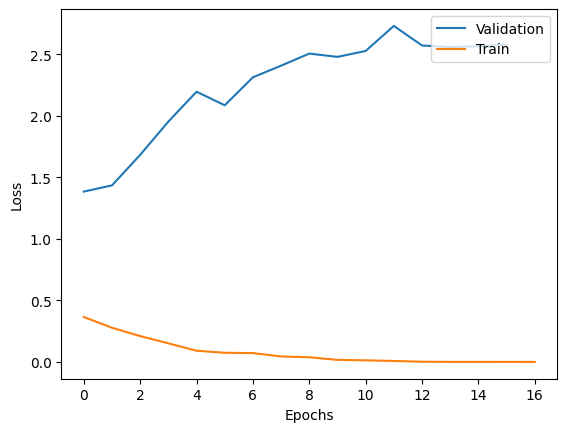

In [16]:
import matplotlib.pyplot as plt

df_log = pd.DataFrame(trainer.state.log_history)

(df_log.dropna(subset=["eval_loss"]).reset_index()["eval_loss"].plot(label="Validation"))
(df_log.dropna(subset=["loss"]).reset_index()["loss"].plot(label="Train"))

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(loc="upper right")
plt.show()

In [18]:
small_test_dataset = tokenized_datasets["test"].shuffle(seed=64).select(range(100))

In [19]:
trainer.evaluate(small_test_dataset)

{'eval_loss': 1.0753791332244873,
 'eval_accuracy': 0.52,
 'eval_runtime': 2.9889,
 'eval_samples_per_second': 33.457,
 'eval_steps_per_second': 4.349,
 'epoch': 3.0}

### 保存模型和训练状态

- 使用 `trainer.save_model` 方法保存模型，后续可以通过 from_pretrained() 方法重新加载
- 使用 `trainer.save_state` 方法保存训练状态

In [20]:
trainer.save_model(model_dir)

In [21]:
trainer.save_state()

In [23]:
# trainer.model.save_pretrained("./")

## Homework: 使用完整的 YelpReviewFull 数据集训练，看 Acc 最高能到多少